<a href="https://colab.research.google.com/github/fabiankmroh/aistudy/blob/master/CIFAR10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
from torch import nn, optim
from torchvision import datasets, transforms

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(DEVICE)

cuda


In [ ]:
BATCH_SIZE = 32
LR = 1e-3
EPOCH = 5
criterion = nn.CrossEntropyLoss()

In [ ]:
new_model_train = False
model_type = "MLP"
dataset = "CIFAR10"

In [ ]:
transform = transforms.ToTensor()
train_DS = datasets.CIFAR10(root = '/content/drive/MyDrive/Colab Notebook/data/CIFAR10', train = True, download = True, transform = transform)
test_DS = datasets.CIFAR10(root = '/content/drive/MyDrive/Colab Notebook/data/CIFAR10', train = False, download = True, transform = transform)

100%|██████████| 170M/170M [00:04<00:00, 42.0MB/s]


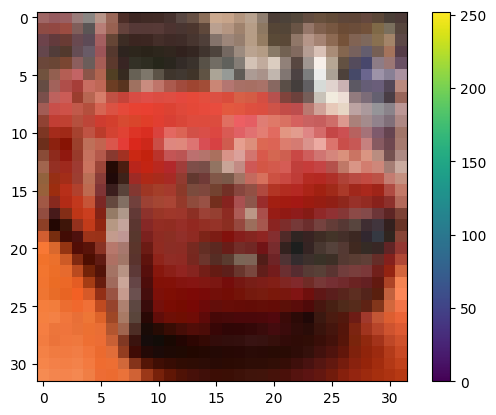

In [ ]:
plt.imshow(train_DS.data[5])
plt.colorbar()

In [ ]:
train_DL = torch.utils.data.DataLoader(train_DS, batch_size = BATCH_SIZE, shuffle = True)
test_DL = torch.utils.data.DataLoader(test_DS, batch_size = BATCH_SIZE, shfufle = True)

NameError: name 'torch' is not defined

In [ ]:
class MLP(nn.Module):
  def __init__(self):
    super().__init__()
    self.fcs = nn.Sequential(
        nn.Linear(28*28, 30),
        nn.BatchNorm1d(30),
        nn.ReLU(),
        nn.Linear(30, 10)
    )

  def forward(self, x):
    x = torch.flatten(x, start_dim = 1)
    x = self.fcs(x)
    return x

In [ ]:
BATCH_SIZE = 32
LR = 1e-3
EPOCH = 5
criterion = nn.CrossEntropyLoss()
# This Cell Must be Below Model Declaration
optimizer = optim.Adam(model.parameters(), lr = LR)

In [ ]:
x_batch, _ = next(iter(train_DL))

In [ ]:
if new_model_train:
  optimizer = optim.Adam(model.parameters(), lr = LR)
  loss_history = Train(model, train_DL, criterion, optimizer, EPOCH)

  torch.save(model, save_model_path)

  plt.plot(range(1, EPOCH + 1), loss_history)
  plt.xlabel("Epochs")
  plt.ylabel("Loss")

  plt.title("Train Loss")
  plt.grid()

In [ ]:
def Train(model, train_DL, criterion, optimizer, EPOCH):
  NoT = len(train_DL.dataset) # Number of Training Data
  loss_history = []

  model.train()
  for ep in range(EPOCH):
    rloss = 0
    for x_batch, y_batch in train_DL:
      x_batch = x_batch.to(DEVICE)
      y_batch = y_batch.to(DEVICE)

      pred = model(x_batch) # Prediction / Inference
      loss = criterion(pred, y_batch) # Loss

      optimizer.zero_grad() # Reset Gradient
      loss.backward() # Backpropagation
      optimizer.step() # Weight Update

      # Loss Accumulation
      loss_b = loss.item() * x_batch.shape[0] # Batch Loss
      rloss += loss_b # Running Loss

    # Print Loss
    loss_e = rloss / NoT
    loss_history += [loss_e]

    print(f"Epoch {ep + 1} - Training Loss: {loss_e:.3f}")
    print("-"*30)

  return loss_history

In [ ]:
def Test(model, test_DL):
  model.eval()

  with torch.no_grad():
    rcorrect = 0

    for x_batch, y_batch in test_DL:
      x_batch = x_batch.to(DEVICE)
      y_batch = y_batch.to(DEVICE)

      # Inference
      y_hat = model(x_batch)

      pred = y_hat.argmax(dim = 1)
      corrects_b = torch.sum(pred == y_batch).item()
      rcorrect += corrects_b

    accuracy = rcorrect / len(test_DL.dataset) * 100

  print(f"Test Accuracy: {rcorrect} / {len(test_DL.dataset)} - {accuracy:.1f} %")

  return accuracy

In [ ]:
loss_history = Train(model, train_DL, criterion, optimizer, EPOCH)

In [ ]:
plt.plot(range(1, EPOCH + 1), loss_history)

plt.title("Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid()